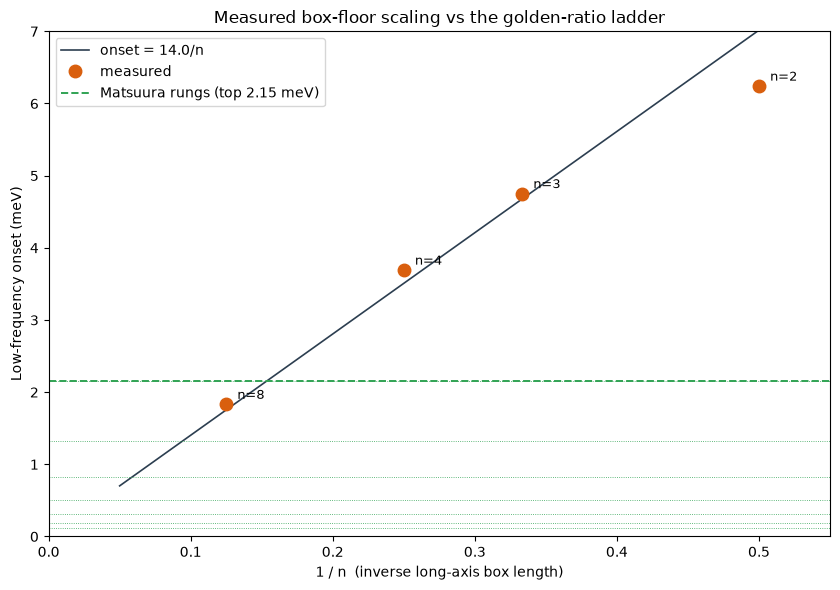

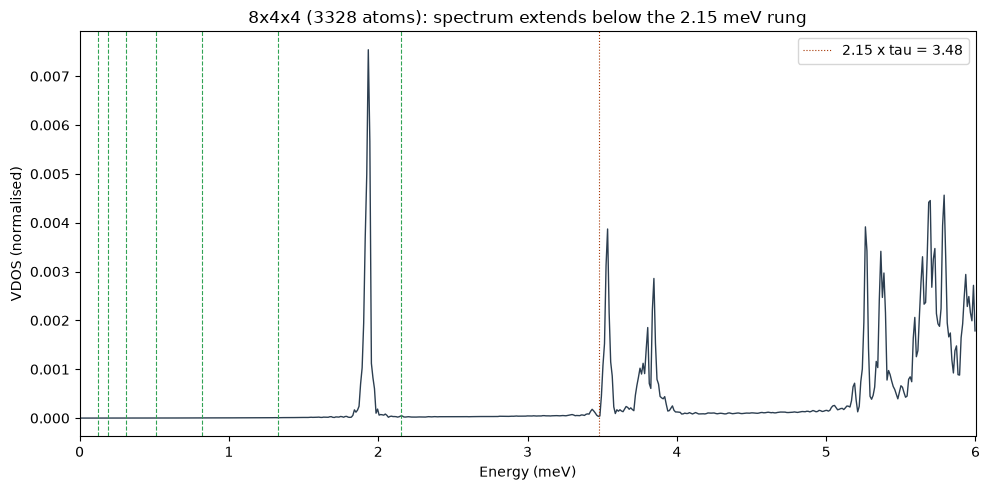

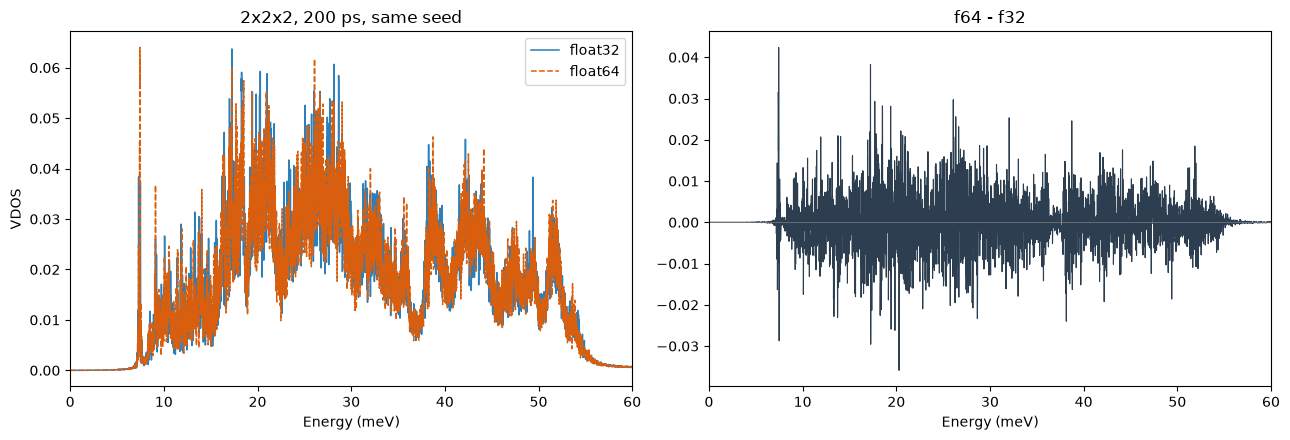

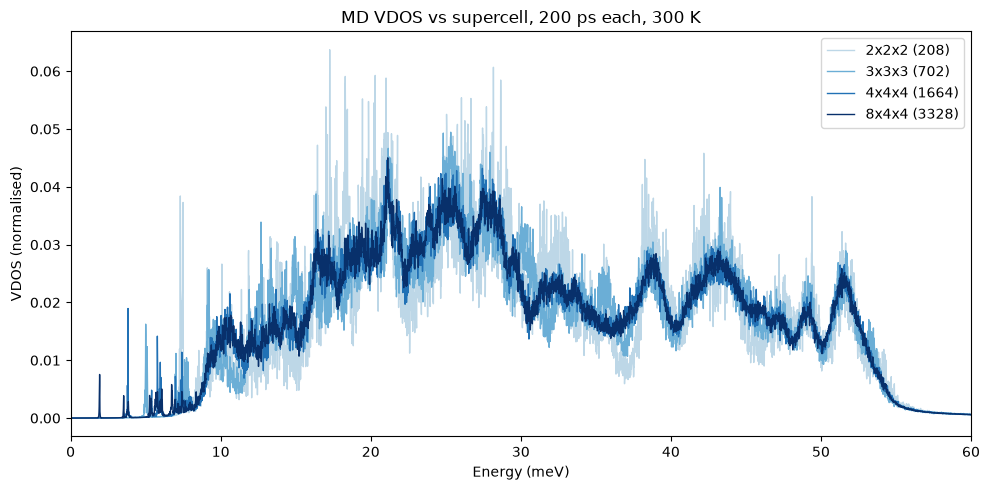

SCALING LAW
onset x n: [12.48 14.25 14.76 14.64]   -> fit A = 14.03
  reach 2.15 meV: n =   6.5  (7,229 atoms if cubic)
  reach 1.33 meV: n =  10.6  (30,537 atoms if cubic)
  reach 0.82 meV: n =  17.1  (130,298 atoms if cubic)
  reach 0.12 meV: n = 116.9  (41,575,240 atoms if cubic)

8x4x4 LOW-FREQUENCY DETAIL
  g( 1.5 meV) = 0.00001
  g(1.83 meV) = 0.00006
  g(1.93 meV) = 0.00669
  g(2.15 meV) = 0.00004
  g( 2.5 meV) = 0.00003
  g( 3.0 meV) = 0.00004
  g(3.43 meV) = 0.00017
  g( 3.5 meV) = 0.00078
  noise reference at 1.0 meV = 0.000004

F64 vs F32
total abs difference: 22.65% of weight
   0-10 meV: 45.27%
  10-30 meV: 24.62%
  30-60 meV: 19.45%

SIZE SERIES: weight below 5 meV (low-freq content grows with box)
     2x2x2 (208): 0.019% of spectral weight below 5 meV
     3x3x3 (702): 0.060% of spectral weight below 5 meV
    4x4x4 (1664): 0.095% of spectral weight below 5 meV
    8x4x4 (3328): 0.088% of spectral weight below 5 meV

figures saved: o3_scaling_law.png, o3_8x4x4_ladder.pn

In [1]:
import numpy as np
import matplotlib.pyplot as plt

TAU = (1 + 5**0.5) / 2
rungs = [0.12, 0.19, 0.31, 0.51, 0.82, 1.33, 2.15]

# ---------- Figure 1: the scaling law, four boxes ----------
n_long = np.array([2, 3, 4, 8])
onset  = np.array([6.24, 4.75, 3.69, 1.83])
A = (onset * n_long).mean()

fig, ax = plt.subplots(figsize=(8.5, 6))
x = np.linspace(0.05, 0.55, 100)
ax.plot(x, A * x, color="#2c3e50", lw=1.2, label=f"onset = {A:.1f}/n")
ax.plot(1/n_long, onset, "o", ms=9, color="#d95f0e", zorder=5, label="measured")
for nn, oo in zip(n_long, onset):
    ax.annotate(f"n={nn}", (1/nn, oo), textcoords="offset points", xytext=(8, 4), fontsize=9)
for r in rungs:
    ax.axhline(r, color="#31a354", lw=0.6, ls=":")
ax.axhline(2.15, color="#31a354", lw=1.4, ls="--", label="Matsuura rungs (top 2.15 meV)")
ax.set_xlabel("1 / n  (inverse long-axis box length)")
ax.set_ylabel("Low-frequency onset (meV)")
ax.set_title("Measured box-floor scaling vs the golden-ratio ladder")
ax.set_xlim(0, 0.55); ax.set_ylim(0, 7); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig("o3_scaling_law.png", dpi=150, bbox_inches="tight"); plt.show()

# ---------- Figure 2: 8x4x4 low-frequency spectrum vs the ladder ----------
f8, s8 = np.load("md_8x4x4_s21_vdos_total.npy")
fig, ax = plt.subplots(figsize=(10, 5))
m = f8 <= 6
ax.plot(f8[m], s8[m], lw=1.0, color="#2c3e50")
for r in rungs:
    ax.axvline(r, color="#31a354", lw=0.8, ls="--")
ax.axvline(3.48, color="#a63603", lw=0.8, ls=":", label="2.15 x tau = 3.48")
ax.set_xlim(0, 6); ax.set_xlabel("Energy (meV)"); ax.set_ylabel("VDOS (normalised)")
ax.set_title("8x4x4 (3328 atoms): spectrum extends below the 2.15 meV rung")
ax.legend()
plt.tight_layout(); plt.savefig("o3_8x4x4_ladder.png", dpi=150, bbox_inches="tight"); plt.show()

# ---------- Figure 3: f64 vs f32 ----------
f32, s32 = np.load("md_2x2x2_s11_vdos_total.npy")
f64, s64 = np.load("md_2x2x2_f64_vdos_total.npy")
diff = np.interp(f32, f64, s64) - s32
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(f32, s32, lw=1.1, color="#2c7fb8", label="float32")
ax[0].plot(f64, s64, lw=1.1, color="#d95f0e", ls="--", label="float64")
ax[0].set_xlim(0, 60); ax[0].legend(); ax[0].set_xlabel("Energy (meV)"); ax[0].set_ylabel("VDOS")
ax[0].set_title("2x2x2, 200 ps, same seed")
ax[1].plot(f32, diff, lw=0.8, color="#2c3e50"); ax[1].axhline(0, color="gray", lw=0.5)
ax[1].set_xlim(0, 60); ax[1].set_xlabel("Energy (meV)"); ax[1].set_title("f64 - f32")
plt.tight_layout(); plt.savefig("o2_f64_vs_f32.png", dpi=150, bbox_inches="tight"); plt.show()

# ---------- Figure 4: size series ----------
series = [("2x2x2 (208)", "md_2x2x2_s11_vdos_total.npy", "#bdd7e7"),
          ("3x3x3 (702)", "md_3x3x3_s12_vdos_total.npy", "#6baed6"),
          ("4x4x4 (1664)", "md_4x4x4_vdos_total.npy",    "#2171b5"),
          ("8x4x4 (3328)", "md_8x4x4_s21_vdos_total.npy", "#08306b")]
fig, ax = plt.subplots(figsize=(10, 5))
for lab, path, c in series:
    ff, ss = np.load(path); ax.plot(ff, ss, lw=1.0, color=c, label=lab)
ax.set_xlim(0, 60); ax.legend(); ax.set_xlabel("Energy (meV)"); ax.set_ylabel("VDOS (normalised)")
ax.set_title("MD VDOS vs supercell, 200 ps each, 300 K")
plt.tight_layout(); plt.savefig("o2_md_size_series.png", dpi=150, bbox_inches="tight"); plt.show()

# ================= NUMBERS TO PASTE =================
print("="*58)
print("SCALING LAW")
print("="*58)
print(f"onset x n: {onset*n_long}   -> fit A = {A:.2f}")
for t in (2.15, 1.33, 0.82, 0.12):
    print(f"  reach {t:>4} meV: n = {A/t:5.1f}  ({26*(A/t)**3:,.0f} atoms if cubic)")

print("\n" + "="*58)
print("8x4x4 LOW-FREQUENCY DETAIL")
print("="*58)
noise = np.interp(1.0, f8, s8)
for E in (1.5, 1.83, 1.93, 2.15, 2.5, 3.0, 3.43, 3.5):
    print(f"  g({E:>4} meV) = {np.interp(E, f8, s8):.5f}")
print(f"  noise reference at 1.0 meV = {noise:.6f}")

print("\n" + "="*58)
print("F64 vs F32")
print("="*58)
print(f"total abs difference: {np.abs(diff).sum()/s32.sum()*100:.2f}% of weight")
for lo, hi in [(0,10),(10,30),(30,60)]:
    mm = (f32>=lo)&(f32<hi)
    print(f"  {lo:2d}-{hi:2d} meV: {np.abs(diff[mm]).sum()/s32[mm].sum()*100:.2f}%")

print("\n" + "="*58)
print("SIZE SERIES: weight below 5 meV (low-freq content grows with box)")
print("="*58)
for lab, path, _ in series:
    ff, ss = np.load(path)
    w = ss[ff < 5].sum() / ss.sum() * 100
    print(f"  {lab:>14}: {w:.3f}% of spectral weight below 5 meV")
print("\nfigures saved: o3_scaling_law.png, o3_8x4x4_ladder.png, o2_f64_vs_f32.png, o2_md_size_series.png")

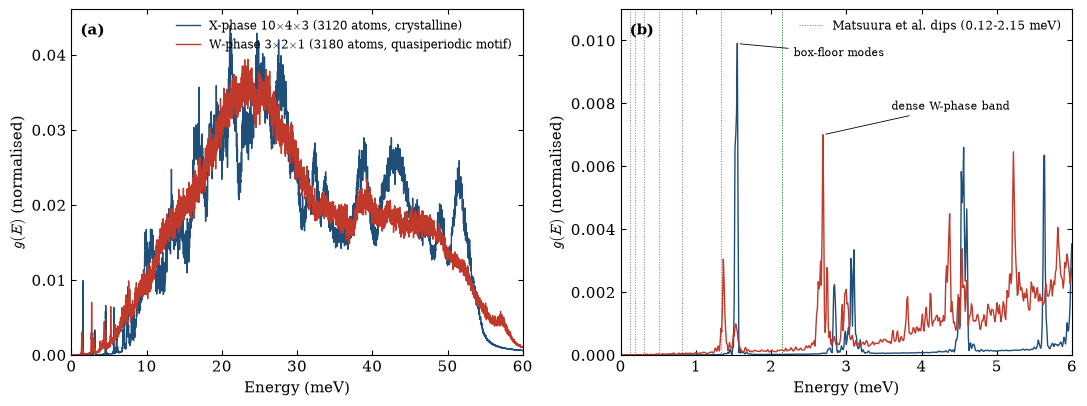

weight below 6 meV:  X 0.199%   W 0.531%
weight 3.2-4.0 meV:  X 0.0054%  W 0.0456%  (ratio 8x)
main peak (10-40 meV): X 21.1  W 23.5 meV


In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "axes.linewidth": 0.8, "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True, "font.size": 11,
})

fx, sx = np.load("md_xphase_10x4x3_vdos_total.npy")   # ordered crystalline (X-phase)
fw, sw = np.load("md_wphase_vdos_total.npy")          # quasiperiodic motif (W-phase)
rungs = [0.12, 0.19, 0.31, 0.51, 0.82, 1.33, 2.15]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) full spectrum
m = fx <= 60
ax[0].plot(fx[m], sx[m], lw=1.0, color="#1f4e79",
           label=r"X-phase 10$\times$4$\times$3 (3120 atoms, crystalline)")
ax[0].plot(fw[fw <= 60], sw[fw <= 60], lw=1.0, color="#c0392b",
           label=r"W-phase 3$\times$2$\times$1 (3180 atoms, quasiperiodic motif)")
ax[0].set_xlim(0, 60); ax[0].set_ylim(0, None)
ax[0].set_xlabel("Energy (meV)"); ax[0].set_ylabel(r"$g(E)$ (normalised)")
ax[0].legend(frameon=False, fontsize=8.5, loc="upper right")
ax[0].text(0.02, 0.96, "(a)", transform=ax[0].transAxes, va="top", fontweight="bold")

# (b) low-frequency zoom with the Matsuura ladder
mzx, mzw = fx <= 6, fw <= 6
ax[1].plot(fx[mzx], sx[mzx], lw=1.0, color="#1f4e79")
ax[1].plot(fw[mzw], sw[mzw], lw=1.0, color="#c0392b")
for r in rungs:
    ax[1].axvline(r, color="#2e7d32", lw=0.7, ls=":", alpha=0.8)
ax[1].axvline(rungs[-1], color="#2e7d32", lw=0.7, ls=":", alpha=0.8,
              label="Matsuura et al. dips (0.12-2.15 meV)")
ax[1].set_xlim(0, 6); ax[1].set_ylim(0, 0.011)
ax[1].set_xlabel("Energy (meV)"); ax[1].set_ylabel(r"$g(E)$ (normalised)")
ax[1].legend(frameon=False, fontsize=8.5, loc="upper right")
ax[1].text(0.02, 0.96, "(b)", transform=ax[1].transAxes, va="top", fontweight="bold")
ax[1].annotate("box-floor modes", xy=(1.55, 0.0099), xytext=(2.3, 0.0095),
               fontsize=8, arrowprops=dict(arrowstyle="-", lw=0.6))
ax[1].annotate("dense W-phase band", xy=(2.69, 0.0070), xytext=(3.6, 0.0078),
               fontsize=8, arrowprops=dict(arrowstyle="-", lw=0.6))

plt.tight_layout()
plt.savefig("fig_crystal_vs_quasicrystal_vdos.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- numbers to paste ----
def w(f, s, lo, hi): return s[(f >= lo) & (f < hi)].sum() / s.sum() * 100
print("weight below 6 meV:  X %.3f%%   W %.3f%%" % (w(fx,sx,0,6), w(fw,sw,0,6)))
print("weight 3.2-4.0 meV:  X %.4f%%  W %.4f%%  (ratio %.0fx)" %
      (w(fx,sx,3.2,4), w(fw,sw,3.2,4), w(fw,sw,3.2,4)/max(w(fx,sx,3.2,4),1e-12)))
print("main peak (10-40 meV): X %.1f  W %.1f meV" %
      (fx[(fx>10)&(fx<40)][np.argmax(sx[(fx>10)&(fx<40)])],
       fw[(fw>10)&(fw<40)][np.argmax(sw[(fw>10)&(fw<40)])]))